In [1]:
import numpy as np
import math
from sympy import *
from scipy import integrate
import matplotlib.pyplot as plt
import random
import time

In [2]:
def chi2(T):
    p = T[0]; q = T[1]; r = T[2]; s = T[3]; t = T[4]; u = T[5]
    S = 0
    if p+q != 0:
        S += ((p-q)**2)/(p+q)
    if r+s != 0:
        S += ((r-s)**2)/(r+s)
    if t+u != 0:
        S += ((t-u)**2)/(t+u)
    return S

In [3]:
def EDOLS_chi2(x,n,m):
    TG = np.zeros((m,6))
    for i in range(m):
        for j in range(n):
            TG[i][int(x[j][i])] += 1
            
    #Step 1
    c = np.zeros((m,n,2))
    for i in range(m):
        T = TG[i]; X = chi2(T)
        for j in range(n):
            if x[j][i] == 0:
                Y = chi2([T[0]-1, T[1], T[2]+1, T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0]-1, T[1], T[2], T[3], T[4]+1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 1:
                Y = chi2([T[0], T[1]-1, T[2], T[3]+1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0], T[1]-1, T[2], T[3], T[4], T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 2:
                Y = chi2([T[0]+1, T[1], T[2]-1, T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0], T[1], T[2]-1, T[3], T[4]+1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 3:
                Y = chi2([T[0], T[1]+1, T[2], T[3]-1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0], T[1], T[2], T[3]-1, T[4], T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 4:
                Y = chi2([T[0]+1, T[1], T[2], T[3], T[4]-1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0], T[1], T[2]+1, T[3], T[4]-1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 5:
                Y = chi2([T[0], T[1]+1, T[2], T[3], T[4], T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0], T[1], T[2], T[3]+1, T[4], T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            
    #Step 2
    LSS = np.zeros(int(2**m)); LS_SIGN = np.zeros(m)
    for j in range(n):
        LSJ = np.zeros((m,int(2**m)))
        LSJ[0][0] = c[0][j][0]; LSJ[0][1] = c[0][j][1]
        for i in range(1,m):
            for k in range(2**i):
                LSJ[i][2*k+0] = LSJ[i-1][k] + c[i][j][0]
                LSJ[i][2*k+1] = LSJ[i-1][k] + c[i][j][1]
        for i in range(int(2**m)):
            if LSS[i] < LSJ[m-1][i]:
                LSS[i] = LSJ[m-1][i]
                for l in range(m):
                    LS_SIGN[l] = int(i/(2**(m-1-l)))%2
    LS = 0
    for i in range(int(2**m)):
        if LS < LSS[i]:
            LS = LSS[i]
            for l in range(m):
                LS_SIGN[l] = int(i/(2**(m-1-l)))%2
    #print(LS_SIGN)
        
    #Step 3
    EDOLS = np.zeros((m,2)) #\hat{LS}^{i+-}
    
    for j in range(m):
        for i in range(int(2**m)):
            if int(i/(2**(m-1-j)))%2 == 0:
                EDOLS[j][0] = max(EDOLS[j][0], LSS[i])
            else:
                EDOLS[j][1] = max(EDOLS[j][1], LSS[i])
    #print(EDOLS[:,0], EDOLS[:,1])
    
    #Step 4
    for i in range(m):
        if LS_SIGN[i] == 0:
            d = 1
        else:
            d = 0
        EDOLS[i][d] = 0
        for j in range(n):
            for s in range(int(2**m)):
                if int(s/(2**(m-1-i)))%2 == d:
                    t = 0
                    for l in range(m):
                        if l != i and EDOLS[l][int(s/(2**(m-1-l)))%2] != 0:
                            t += c[l][j][int(s/(2**(m-1-l)))%2]/EDOLS[l][int(s/(2**(m-1-l)))%2]
                    if t != 1:
                        EDOLS[i][d] = max(EDOLS[i][d], c[i][j][d]/(1-t))
    #print(EDOLS)
    return EDOLS[:,0], EDOLS[:,1]

In [4]:
def DOLS_chi2(x,n,m):
    TG = np.zeros((m,6))
    for i in range(m):
        for j in range(n):
            TG[i][int(x[j][i])] += 1
            
    #Step 1
    MCP = np.zeros((m,6)); MCN = np.zeros((m,6)) #MaxChange
    for i in range(m):
        T = TG[i]
        X = chi2(T); MCP[i] = np.zeros(6); MCN[i] = np.zeros(6)
        if T[0] >= 1:
            Y = chi2([T[0]-1, T[1], T[2]+1, T[3], T[4], T[5]])
            MCP[i][0] = max(MCP[i][0], Y-X); MCN[i][0] = max(MCN[i][0], X-Y)
            Y = chi2([T[0]-1, T[1], T[2], T[3], T[4]+1, T[5]])
            MCP[i][0] = max(MCP[i][0], Y-X); MCN[i][0] = max(MCN[i][0], X-Y)
        if T[1] >= 1:
            Y = chi2([T[0], T[1]-1, T[2], T[3]+1, T[4], T[5]])
            MCP[i][1] = max(MCP[i][1], Y-X); MCN[i][1] = max(MCN[i][1], X-Y)
            Y = chi2([T[0], T[1]-1, T[2], T[3], T[4], T[5]+1])
            MCP[i][1] = max(MCP[i][1], Y-X); MCN[i][1] = max(MCN[i][1], X-Y)
        if T[2] >= 1:
            Y = chi2([T[0]+1, T[1], T[2]-1, T[3], T[4], T[5]])
            MCP[i][2] = max(MCP[i][2], Y-X); MCN[i][2] = max(MCN[i][2], X-Y)
            Y = chi2([T[0], T[1], T[2]-1, T[3], T[4]+1, T[5]])
            MCP[i][2] = max(MCP[i][2], Y-X); MCN[i][2] = max(MCN[i][2], X-Y)
        if T[3] >= 1:
            Y = chi2([T[0], T[1]+1, T[2], T[3]-1, T[4], T[5]])
            MCP[i][3] = max(MCP[i][3], Y-X); MCN[i][3] = max(MCN[i][3], X-Y)
            Y = chi2([T[0], T[1], T[2], T[3]-1, T[4], T[5]+1])
            MCP[i][3] = max(MCP[i][3], Y-X); MCN[i][3] = max(MCN[i][3], X-Y)
        if T[4] >= 1:
            Y = chi2([T[0]+1, T[1], T[2], T[3], T[4]-1, T[5]])
            MCP[i][4] = max(MCP[i][4], Y-X); MCN[i][4] = max(MCN[i][4], X-Y)
            Y = chi2([T[0], T[1], T[2]+1, T[3], T[4]-1, T[5]])
            MCP[i][4] = max(MCP[i][4], Y-X); MCN[i][4] = max(MCN[i][4], X-Y)
        if T[5] >= 1:
            Y = chi2([T[0], T[1]+1, T[2], T[3], T[4], T[5]-1])
            MCP[i][5] = max(MCP[i][5], Y-X); MCN[i][5] = max(MCN[i][5], X-Y)
            Y = chi2([T[0], T[1], T[2], T[3]+1, T[4], T[5]-1])
            MCP[i][5] = max(MCP[i][5], Y-X); MCN[i][5] = max(MCN[i][5], X-Y)
    
    #Step 2
    LSS = np.zeros(int(2**m))
    for j in range(n):
        LSJ = np.zeros((m,int(2**m)))
        LSJ[0][0] = MCP[0][int(x[j][0])]; LSJ[0][1] = MCN[0][int(x[j][0])]
        #print(LSJ[0],LSJ[1])
        for i in range(1,m):
            for k in range(2**i):
                LSJ[i][2*k+0] = LSJ[i-1][k] + MCP[i][int(x[j][i])]
                LSJ[i][2*k+1] = LSJ[i-1][k] + MCN[i][int(x[j][i])]
        #print(LSJ)
        for i in range(int(2**m)):
            LSS[i] = max(LSS[i],LSJ[m-1][i])    
        #print(LSS)
        
    #Step 3
    DOLSP = np.zeros(m) #LS^{i+}
    DOLSN = np.zeros(m) #LS^{i-}
    
    for j in range(m):
        for i in range(int(2**m)):
            if int(i/(2**(m-1-j)))%2 == 0:
                DOLSP[j] = max(DOLSP[j], LSS[i])
            else:
                DOLSN[j] = max(DOLSN[j], LSS[i])
    
    return DOLSP, DOLSN

In [5]:
def NeighboringY(x,n,m):
    y = np.ones((n,int(2**m),n,m))
    for i in range(n):
        for j in range(int(2**m)):
            for k in range(m):
                l = int(j/(2**(m-1-k)))%2
                if x[i][k] == 0:
                    if l == 0:
                        y[i][j][i][k] = 2
                    else:
                        y[i][j][i][k] = 4
                if x[i][k] == 1:
                    if l == 0:
                        y[i][j][i][k] = 3
                    else:
                        y[i][j][i][k] = 5
                if x[i][k] == 2:
                    if l == 0:
                        y[i][j][i][k] = 0
                    else:
                        y[i][j][i][k] = 4
                if x[i][k] == 3:
                    if l == 0:
                        y[i][j][i][k] = 1
                    else:
                        y[i][j][i][k] = 5
                if x[i][k] == 4:
                    if l == 0:
                        y[i][j][i][k] = 0
                    else:
                        y[i][j][i][k] = 2
                if x[i][k] == 5:
                    if l == 0:
                        y[i][j][i][k] = 1
                    else:
                        y[i][j][i][k] = 3
    return y

def EDOSS_chi2(x,n,m,eps): #Th.4
    EDOSSP = np.zeros((m,len(eps))); EDOSSN = np.zeros((m,len(eps)))
    for i in range(m):
        EDOLSP, EDOLSN = EDOLS_chi2(x,n,m)
        for neps in range(len(eps)):
            EDOSSP[i][neps] = max([EDOLSP[i], EDOLSN[i]*math.exp(-2*(eps[neps]/4))])
            EDOSSN[i][neps] = max([EDOLSN[i], EDOLSP[i]*math.exp(-2*(eps[neps]/4))])
    y = NeighboringY(x,n,m)
    t = np.zeros((m,len(eps)))
    for j in range(n):
        for i in range(int(2**m)):
            DOLSP, DOLSN = DOLS_chi2(y[j][i],n,m)
            for l in range(m):
                for neps in range(len(eps)):
                    t[l][neps] = max([t[l][neps],max([DOLSP[l],DOLSN[l]])*math.exp(-(eps[neps]/4))])
            yy = NeighboringY(y[j][i],n,m)
            for jj in range(n):
                for ii in range(int(2**m)):
                    DOLSP, DOLSN = DOLS_chi2(yy[jj][ii],n,m)
                    for l in range(m):
                        for neps in range(len(eps)):
                            t[l][neps] = max([t[l][neps],max([DOLSP[l],DOLSN[l]])*math.exp(-2*(eps[neps]/4))])
    for i in range(m):
        for neps in range(len(eps)):
            EDOSSP[i][neps] = max([EDOSSP[i][neps],t[i][neps]])
            EDOSSN[i][neps] = max([EDOSSN[i][neps],t[i][neps]])
    return EDOSSP, EDOSSN

In [6]:
def h3(z,l):
    return (3*np.sqrt(3)*(l**(2/3)))/(4*math.pi*(math.fabs(z)**3+l))

def cdf(x,h,l):
    g = lambda z: h(z,l)
    return integrate.quad(g,-oo,x)

def noise(h,l,d): # using inverse transform sampling
    r = np.random.rand()
    q = 1000; z = 10
    for i in range(-50,50):
        if math.fabs(r - cdf(i/5,h,l)[0]) > q:
            z = (i-1)/5
            break
        else:
            q = min(q, math.fabs(r - cdf(i/5,h,l)[0]))
    if d == 0:
        return math.fabs(z)
    elif d == 1:
        return -math.fabs(z)
    
def alpha(k,l,m,ei): #epsilon = ei*m
    return ((l**(1/k))*(ei*m))/(2*((k-1)**((k-1)/k)))

In [7]:
def DOSS_chi2_test(n,m):
    GS = (4*n/(n+2))*m
    x = np.ones((n,m))
    while(1):
        f = 0
        for j in range(m):
            x[:,j] = np.ones(n); T = np.zeros(6)
            case = random.sample(range(n), k=int(n/2))
            for i in range(int(n/2)):
                r = random.random()
                if r < 1/3:
                    x[case[i]][j] = 0; T[0] += 1
                elif r < 2/3:
                    x[case[i]][j] = 2; T[2] += 1
                else:
                    x[case[i]][j] = 4; T[4] += 1
            for i in range(n):
                if x[i][j] == 1:
                    r = random.random()
                    if r < 2/n:
                        x[i][j] = 1; T[1] += 1
                    elif r < 1/2:
                        x[i][j] = 3; T[3] += 1
                    else:
                        x[i][j] = 5; T[5] += 1
            if chi2(T) == 0 and chi2(T) == n:
                f = 1
        EDOLSP, EDOLSN = EDOLS_chi2(x,n,m)
        for i in range(m):
            if EDOLSP[i] == 0 or EDOLSN[i] == 0:
                f = 1
            elif GS/max([EDOLSP[i],EDOLSN[i]]) >= math.exp(15/4):
                f = 1
        if f == 0:
            break
    return x

In [8]:
def accuracy(n,m,DOSSP,DOSSN,EDOSSP,EDOSSN):
    acc = np.zeros((8,3))
    k = 3; l = 3
    SS = np.zeros(20)
    ei = [15+5*i for i in range(8)]
    
    for j in range(20):
        SS[j] = max(max(DOSSP[j]), max(DOSSN[j]))
        for i in range(8):
            for t in range(m):
                if random.random()<0.5:
                    z = noise(h3,l,0)
                    acc[i][0] += math.fabs((EDOSSP[t][i]/alpha(k,l,m,ei[i]))*z)
                    acc[i][1] += math.fabs((DOSSP[j][t]/alpha(k,l,m,ei[i]))*z)
                    acc[i][2] += math.fabs((SS[j]/alpha(k,l,m,ei[i]))*z)
                else:
                    z = noise(h3,l,1)
                    acc[i][0] += math.fabs((EDOSSN[t][i]/alpha(k,l,m,ei[i]))*z)
                    acc[i][1] += math.fabs((DOSSN[j][t]/alpha(k,l,m,ei[i]))*z)
                    acc[i][2] += math.fabs((SS[j]/alpha(k,l,m,ei[i]))*z)
    return acc/(m*20)

[[0.42186261 0.53081759 0.59086942]
 [0.44228976 0.48961282 0.51935546]
 [0.23905287 0.28118866 0.30575148]
 [0.28776503 0.33032642 0.35561585]
 [0.16510092 0.21270008 0.24050127]
 [0.18140208 0.21291389 0.23154109]
 [0.14499938 0.18255759 0.20373011]
 [0.12375999 0.15206682 0.167413  ]]
[[0.44096344 0.51755866 0.56429592]
 [0.39078223 0.44945778 0.48418466]
 [0.34616137 0.38547061 0.41079493]
 [0.2102131  0.25565806 0.28136639]
 [0.24503911 0.2855237  0.30883311]
 [0.16881239 0.21443585 0.24033379]
 [0.1865583  0.21999785 0.24020353]
 [0.11128253 0.13818912 0.15334468]]
[[0.62292232 0.76797434 0.85347805]
 [0.38688831 0.44343465 0.47832286]
 [0.35597125 0.38136786 0.39672661]
 [0.21558266 0.26915469 0.29934258]
 [0.2063103  0.26346287 0.29610463]
 [0.18286874 0.21674142 0.23798907]
 [0.16451287 0.19337278 0.21102479]
 [0.14018665 0.15448723 0.16272356]]
[[0.44285004 0.5277267  0.5768011 ]
 [0.35844289 0.43060645 0.47246106]
 [0.233873   0.28353521 0.3113788 ]
 [0.21429559 0.24707457 0

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


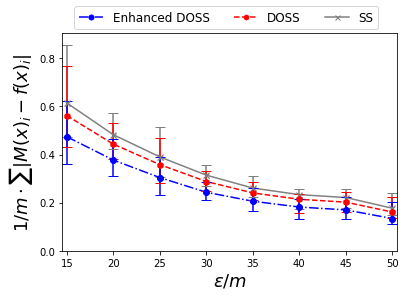

In [9]:
n = 150; m = 3

acc = np.zeros((8,3))
max_acc = np.zeros((8,3)); min_acc = np.ones((8,3))
sum_acc = np.zeros((8,3))

x = DOSS_chi2_test(n,m)

DOSSP = np.zeros((20,m)); DOSSN = np.zeros((20,m))
for i in range(20):
    DOSSP[i], DOSSN[i] = DOLS_chi2(x,n,m)
    
ei = [15+5*i for i in range(8)]
EDOSSP, EDOSSN = EDOSS_chi2(x,n,m,ei)
#print(EDOSSP, EDOSSN)

jj = 10
for j in range(jj):
    acc = accuracy(n,m,DOSSP,DOSSN,EDOSSP,EDOSSN)
    for i in range(8):
        for k in range(3):
            max_acc[i][k] = max(max_acc[i][k], acc[i][k])
            min_acc[i][k] = min(min_acc[i][k], acc[i][k])
            sum_acc[i][k] += acc[i][k]
    print(acc)
acc = sum_acc/jj

y_err = np.zeros((2,8,3))
for k in range(3):
    y_err[0,:,k] = acc[:,k] - min_acc[:,k]
    y_err[1,:,k] = max_acc[:,k] - acc[:,k]

ei = [15+5*i for i in range(8)]

print(acc)
fig = plt.figure()
plt.ylim(0, max(max_acc[i][j] for i in range(8) for j in range(3))+0.05)
plt.xlim(14.5, 50.5)
plt.plot(ei, acc[:,0], marker="o", markersize=5, color = "blue", linestyle = "dashdot", label = "Enhanced DOSS")
plt.plot(ei, acc[:,1], marker="h", markersize=5, color = "red", linestyle = "--", label = "DOSS")
plt.plot(ei, acc[:,2], marker="x", markersize=5, color = "gray", linestyle = "-", label = "SS")
plt.errorbar(ei, acc[:,2], yerr = y_err[:,:,2], capsize=5, fmt='x', ecolor='gray', markeredgecolor = "gray", color='gray')
plt.errorbar(ei, acc[:,1], yerr = y_err[:,:,1], capsize=5, fmt='h', ecolor='red', markeredgecolor = "red", color='red')
plt.errorbar(ei, acc[:,0], yerr = y_err[:,:,0], capsize=5, fmt='o', ecolor='blue', markeredgecolor = "blue", color='blue')
plt.legend(bbox_to_anchor=(0.49, 1.02), loc='lower center', borderaxespad=0, ncol=3, fontsize=12)
plt.xlabel("$\epsilon/m$", fontsize = 18)
plt.ylabel("$1/m \cdot \sum |M(x)_i - f(x)_i|$", fontsize = 18)
fig.savefig("Accuracy_chi2_m=3.png")
fig.savefig("figs/Accuracy_chi2_m=3.eps", bbox_inches="tight", pad_inches=0.05)